# Часть 2А — Классификация описаний транзакций

**Задача:** классифицировать поле `description` транзакции в одну из 20 категорий.

**Два подхода:**
1. **Keyword/regex baseline** — поиск ключевых слов из `categories.json`
2. **ML-классификатор** — TF-IDF (word + char n-grams) + Logistic Regression

**Оценка** — только на `gold_set.csv` (200 строк). Gold set **не используется** для обучения.

In [4]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src'))

DATA = ROOT / 'data'

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score
)

from classifier import (
    load_categories, KeywordClassifier, MLClassifier, build_training_data
)

print('OK — всё импортировано')

OK — всё импортировано


## 1. Загрузка данных

In [6]:
categories = load_categories(DATA / 'categories.json')
gold = pd.read_csv(DATA / 'gold_set.csv')
gold['category_code'] = gold['category_code'].astype(str)

# Словарь code -> name для красивых подписей
code2name = {code: info['name'] for code, info in categories.items()}

print(f'Категорий: {len(categories)}')
print(f'Gold set:  {len(gold)} строк')
print(f'Классов в gold set: {gold["category_code"].nunique()}')
gold.head(3)

Категорий: 20
Gold set:  200 строк
Классов в gold set: 20


,description,category_code,category_name
0,"Доставка груза 5 тонн, маршрут Шымкент-Тараз",49.41,Услуги перевозки грузов автотранспортом
1,Дизельное топливо 5000 л,19.2,Топливо и ГСМ
2,"Офисная мебель: столы, стулья — 15 рабочих мест",31.01,Мебель и офисное оборудование


## 2. Keyword / Regex Baseline

In [8]:
kw_clf = KeywordClassifier(categories)

kw_preds = kw_clf.predict(gold['description'].tolist())

gold_kw = gold.copy()
gold_kw['pred_code']   = kw_preds['pred_code']
gold_kw['pred_name']   = kw_preds['pred_name']
gold_kw['confidence']  = kw_preds['confidence']

# Сколько не смогли классифицировать
n_unclassified = gold_kw['pred_code'].isna().sum()
print(f'Не распознано (нет ключевых слов): {n_unclassified} / {len(gold_kw)}')

Не распознано (нет ключевых слов): 11 / 200


In [9]:
# Метрики baseline (только на тех, где есть предсказание)
gold_kw_eval = gold_kw.dropna(subset=['pred_code'])

y_true_kw = gold_kw_eval['category_code'].tolist()
y_pred_kw = gold_kw_eval['pred_code'].tolist()

# Исправляем формат: category_code может быть '49.41' или '49.4100000001'
# Нормализуем через round
def norm_code(c):
    try:
        return f'{float(c):.2f}'
    except:
        return str(c)

y_true_kw = [norm_code(c) for c in y_true_kw]
y_pred_kw = [norm_code(c) for c in y_pred_kw]

labels_kw = sorted(set(y_true_kw) | set(y_pred_kw))
target_names_kw = [code2name.get(c, c) for c in labels_kw]

print('=== Keyword Baseline — отчёт по классам ===')
print(classification_report(
    y_true_kw, y_pred_kw,
    labels=labels_kw,
    target_names=target_names_kw,
    zero_division=0
))

=== Keyword Baseline — отчёт по классам ===
                                           precision    recall  f1-score   support

                                     1.11       1.00      1.00      1.00        10
                   Продукты питания (опт)       1.00      1.00      1.00         8
                         Спецодежда и СИЗ       1.00      0.80      0.89        10
     Бумажные канцелярские принадлежности       1.00      1.00      1.00        10
                            Топливо и ГСМ       1.00      1.00      1.00        10
           Медицинские товары и препараты       0.83      1.00      0.91        10
                   Строительные материалы       1.00      1.00      1.00        10
         Транспортные средства и запчасти       1.00      1.00      1.00        10
            Мебель и офисное оборудование       1.00      1.00      1.00        10
Коммунальные услуги (электро, газ, тепло)       1.00      1.00      1.00         5
  Услуги перевозки грузов автотранспортом 

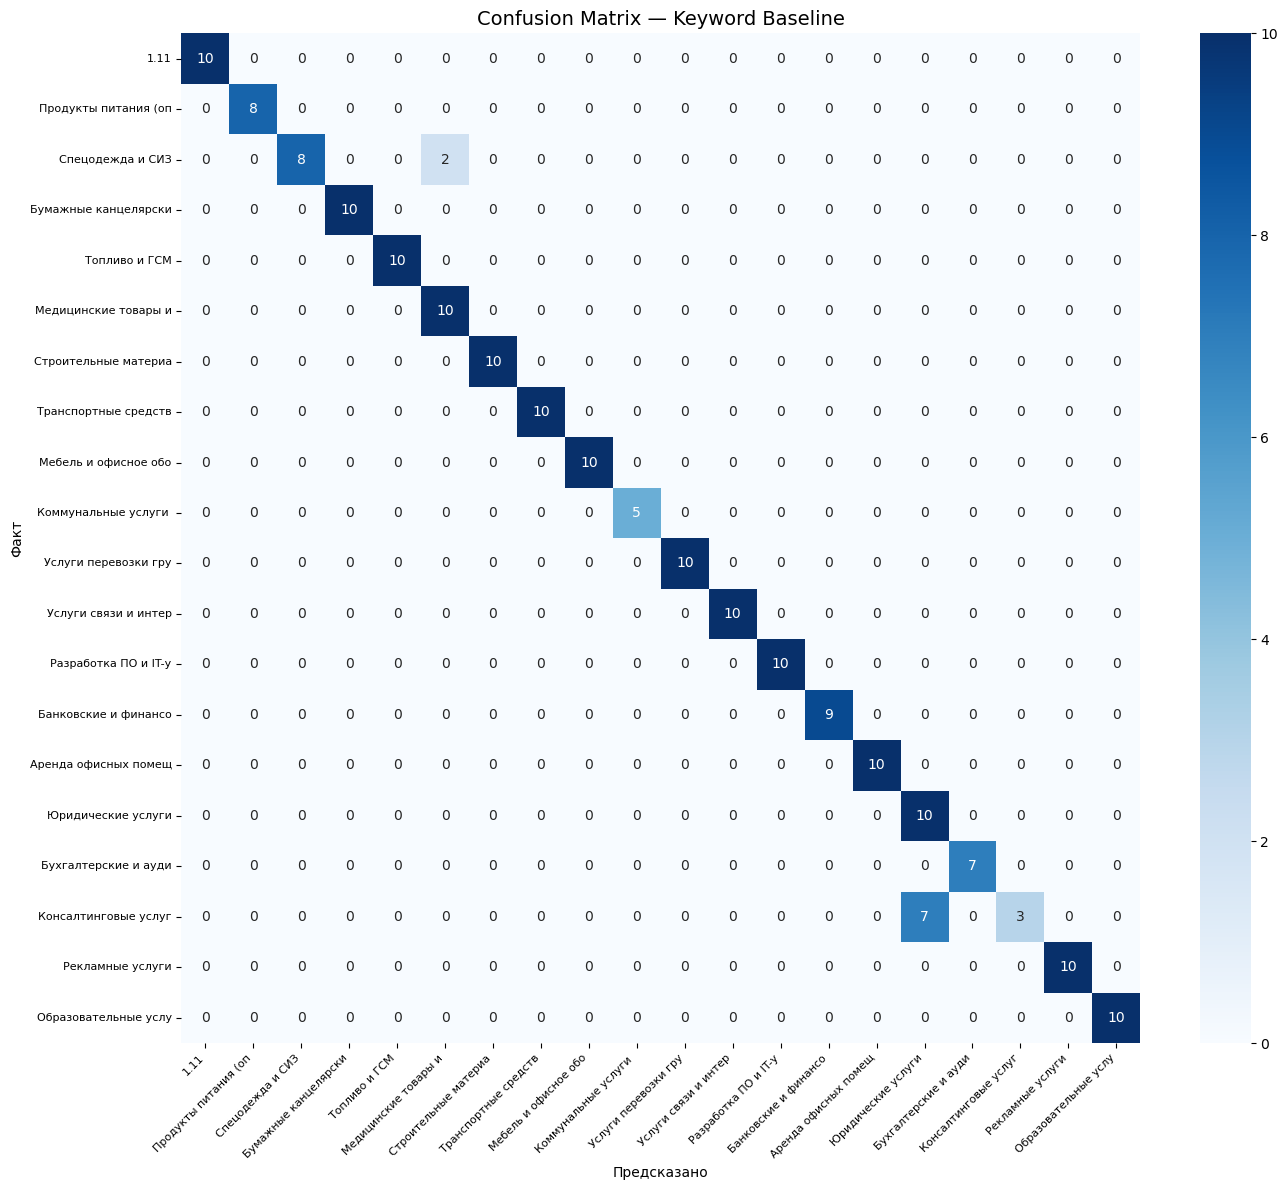

Сохранено: confusion_baseline.png


In [10]:
# Confusion matrix baseline
short_names = {code: name[:20] for code, name in code2name.items()}
labels_short = [short_names.get(c, c) for c in labels_kw]

cm_kw = confusion_matrix(y_true_kw, y_pred_kw, labels=labels_kw)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm_kw, annot=True, fmt='d', cmap='Blues',
    xticklabels=labels_short, yticklabels=labels_short, ax=ax
)
ax.set_title('Confusion Matrix — Keyword Baseline', fontsize=14)
ax.set_xlabel('Предсказано')
ax.set_ylabel('Факт')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'confusion_baseline.png', dpi=120)
plt.show()
print('Сохранено: confusion_baseline.png')

## 3. ML-классификатор: TF-IDF + LogisticRegression

In [12]:
# Строим обучающую выборку из transactions.csv
# Gold set НЕ входит в обучение
print('Разметка transactions.csv ключевыми словами...')
train_df = build_training_data(
    DATA / 'transactions.csv',
    categories,
    min_confidence=0.5
)
print(f'Обучающая выборка: {len(train_df)} строк')
print(f'Классов в обучении: {train_df["category_code"].nunique()}')
train_df['category_code'].value_counts().head(10)

Разметка transactions.csv ключевыми словами...
Обучающая выборка: 65848 строк
Классов в обучении: 20


category_code
49.41    9227
17.23    7228
23.61    6180
62.01    4764
01.11    3080
61.10    3065
29.10    3033
85.42    3030
73.11    3027
21.20    3026
Name: count, dtype: Int64

In [13]:
# Обучение
print('Обучение TF-IDF + LogReg...')
ml_clf = MLClassifier()
ml_clf.fit(
    train_df['description'].tolist(),
    train_df['category_code'].tolist()
)
print('Обучение завершено.')
print(f'Классов в модели: {len(ml_clf.classes_)}')

Обучение TF-IDF + LogReg...
Обучение завершено.
Классов в модели: 20


In [14]:
# Предсказание на gold_set
ml_preds = ml_clf.predict(gold['description'].tolist())

# Добавляем название категории
ml_preds['pred_name'] = ml_preds['pred_code'].map(code2name)

gold_ml = gold.copy()
gold_ml['pred_code']    = ml_preds['pred_code']
gold_ml['pred_name']    = ml_preds['pred_name']
gold_ml['confidence']   = ml_preds['confidence']
gold_ml['needs_review'] = ml_preds['needs_review']

print(f'Требуют ручной проверки (confidence < {MLClassifier.THRESHOLD}): '
      f'{gold_ml["needs_review"].sum()} / {len(gold_ml)}')
gold_ml.head(5)

Требуют ручной проверки (confidence < 0.4): 11 / 200


,description,category_code,category_name,pred_code,pred_name,confidence,needs_review
0,"Доставка груза 5 тонн, маршрут Шымкент-Тараз",49.41,Услуги перевозки грузов автотранспортом,49.41,Услуги перевозки грузов автотранспортом,1.0000,False
1,Дизельное топливо 5000 л,19.2,Топливо и ГСМ,19.20,Топливо и ГСМ,0.9998,False
2,"Офисная мебель: столы, стулья — 15 рабочих мест",31.01,Мебель и офисное оборудование,31.01,Мебель и офисное оборудование,0.5483,False
3,Услуги: лекарственные препараты по заявке №21,21.2,Медицинские товары и препараты,21.20,Медицинские товары и препараты,0.9993,False
4,хлебобулочные изделия — партия №14,10.71,Продукты питания (опт),10.71,Продукты питания (опт),0.9997,False


In [15]:
# Метрики ML
y_true_ml = [norm_code(c) for c in gold_ml['category_code'].tolist()]
y_pred_ml = [norm_code(c) for c in gold_ml['pred_code'].tolist()]

labels_ml = sorted(set(y_true_ml) | set(y_pred_ml))
target_names_ml = [code2name.get(c, c) for c in labels_ml]

print('=== TF-IDF + LogReg — отчёт по классам ===')
print(classification_report(
    y_true_ml, y_pred_ml,
    labels=labels_ml,
    target_names=target_names_ml,
    zero_division=0
))

=== TF-IDF + LogReg — отчёт по классам ===
                                           precision    recall  f1-score   support

                                     1.11       0.83      1.00      0.91        10
                   Продукты питания (опт)       1.00      0.60      0.75        10
                         Спецодежда и СИЗ       1.00      1.00      1.00        10
     Бумажные канцелярские принадлежности       1.00      0.80      0.89        10
                            Топливо и ГСМ       1.00      1.00      1.00        10
           Медицинские товары и препараты       1.00      1.00      1.00        10
                   Строительные материалы       1.00      1.00      1.00        10
         Транспортные средства и запчасти       1.00      1.00      1.00        10
            Мебель и офисное оборудование       0.83      1.00      0.91        10
Коммунальные услуги (электро, газ, тепло)       1.00      1.00      1.00        10
  Услуги перевозки грузов автотранспортом  

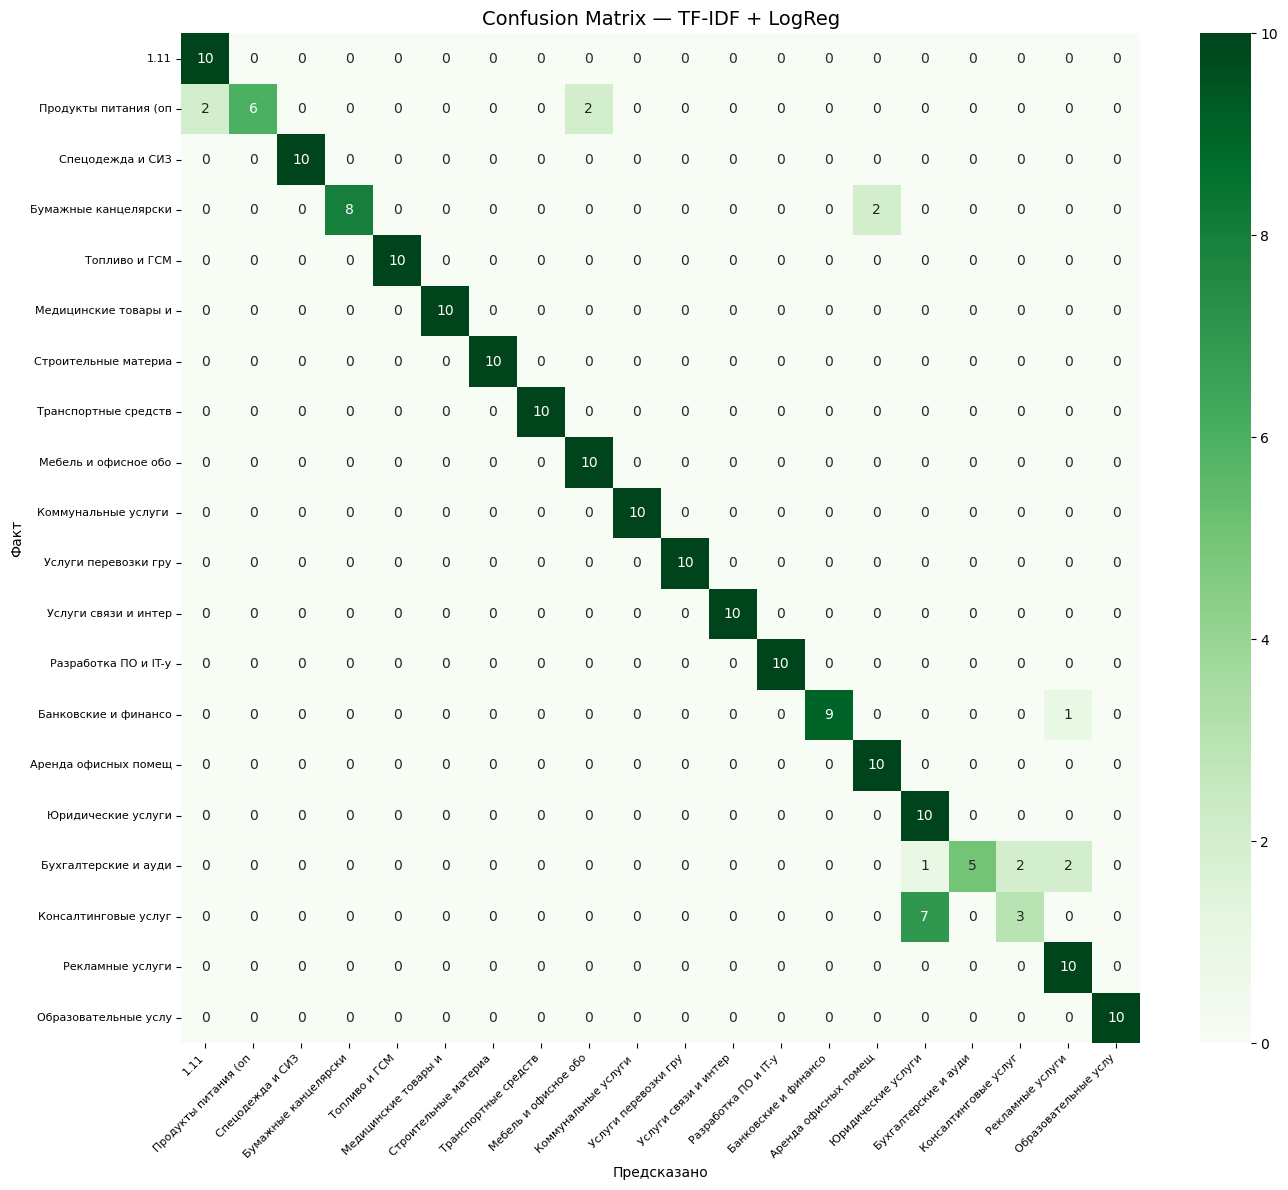

Сохранено: confusion_ml.png


In [16]:
# Confusion matrix ML
cm_ml = confusion_matrix(y_true_ml, y_pred_ml, labels=labels_ml)

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(
    cm_ml, annot=True, fmt='d', cmap='Greens',
    xticklabels=labels_short, yticklabels=labels_short, ax=ax
)
ax.set_title('Confusion Matrix — TF-IDF + LogReg', fontsize=14)
ax.set_xlabel('Предсказано')
ax.set_ylabel('Факт')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'confusion_ml.png', dpi=120)
plt.show()
print('Сохранено: confusion_ml.png')

## 4. Сравнение двух подходов

In [18]:
# Macro F1 для сравнения
f1_kw = f1_score(y_true_kw, y_pred_kw, average='macro', zero_division=0)
f1_ml = f1_score(y_true_ml, y_pred_ml, average='macro', zero_division=0)

# Accuracy
acc_kw = (np.array(y_true_kw) == np.array(y_pred_kw)).mean()
acc_ml = (np.array(y_true_ml) == np.array(y_pred_ml)).mean()

# Покрытие baseline (доля транзакций, где нашлось хоть одно ключевое слово)
coverage_kw = 1 - n_unclassified / len(gold)

comparison = pd.DataFrame({
    'Метрика': ['Accuracy (gold set)', 'Macro F1 (gold set)', 'Покрытие'],
    'Keyword Baseline': [f'{acc_kw:.3f}', f'{f1_kw:.3f}', f'{coverage_kw:.3f}'],
    'TF-IDF + LogReg':  [f'{acc_ml:.3f}', f'{f1_ml:.3f}', '1.000'],
})
display(comparison)

print(f'\nKeyword baseline — Accuracy: {acc_kw:.1%}, Macro F1: {f1_kw:.3f}, Покрытие: {coverage_kw:.1%}')
print(f'TF-IDF + LogReg  — Accuracy: {acc_ml:.1%}, Macro F1: {f1_ml:.3f}, Покрытие: 100%')

,Метрика,Keyword Baseline,TF-IDF + LogReg
0,Accuracy (gold set),0.952,0.905
1,Macro F1 (gold set),0.950,0.898
2,Покрытие,0.945,1.000



Keyword baseline — Accuracy: 95.2%, Macro F1: 0.950, Покрытие: 94.5%
TF-IDF + LogReg  — Accuracy: 90.5%, Macro F1: 0.898, Покрытие: 100%


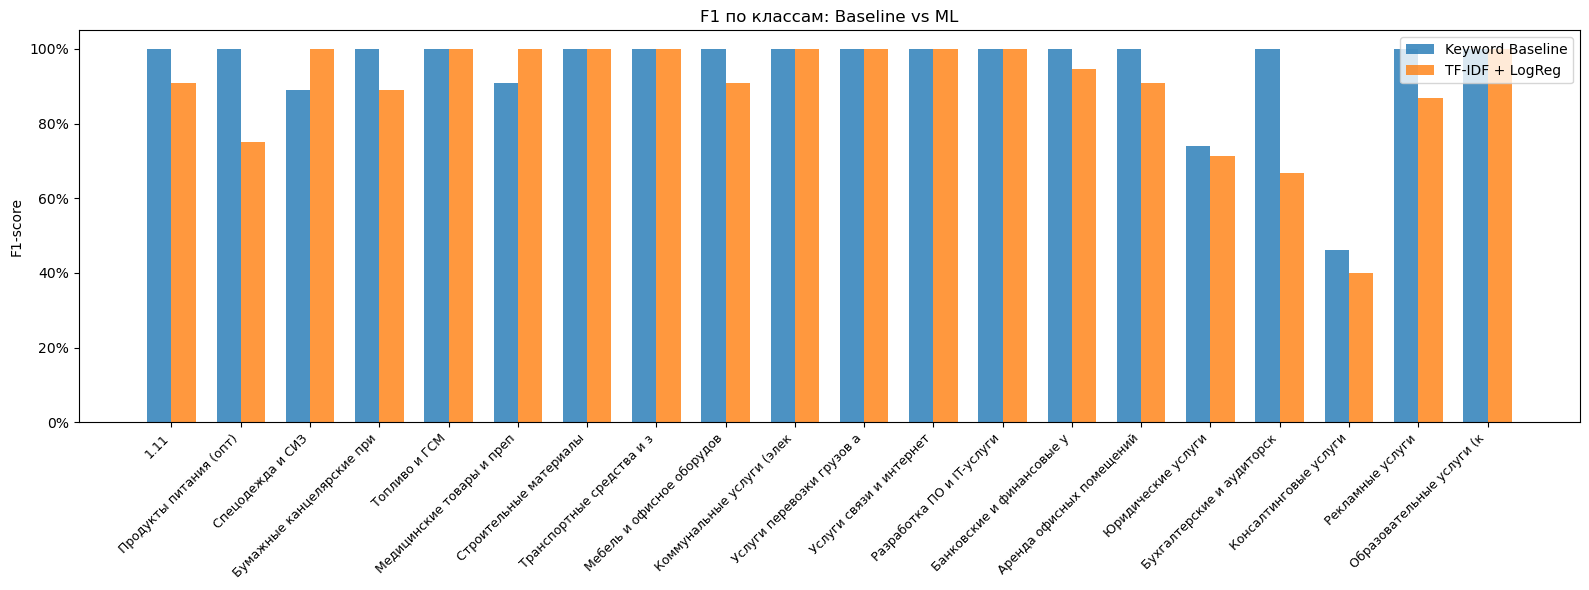

Сохранено: f1_comparison.png


In [19]:
# F1 по классам — сравнение на барчарте
from sklearn.metrics import f1_score as f1

# Общий набор классов
all_labels = sorted(set(y_true_ml))
all_names  = [code2name.get(c, c)[:25] for c in all_labels]

f1_per_class_kw = f1(y_true_kw, y_pred_kw, labels=all_labels, average=None, zero_division=0)
f1_per_class_ml = f1(y_true_ml, y_pred_ml, labels=all_labels, average=None, zero_division=0)

x = np.arange(len(all_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 6))
ax.bar(x - width/2, f1_per_class_kw, width, label='Keyword Baseline', alpha=0.8)
ax.bar(x + width/2, f1_per_class_ml, width, label='TF-IDF + LogReg',  alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(all_names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('F1-score')
ax.set_title('F1 по классам: Baseline vs ML')
ax.legend()
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'f1_comparison.png', dpi=120)
plt.show()
print('Сохранено: f1_comparison.png')

## 5. Пары с систематической путаницей

По confusion matrix и анализу ключевых слов выделяем 2 пары:

In [21]:
# Находим пары с наибольшим числом взаимных ошибок
cm_df = pd.DataFrame(cm_ml, index=labels_ml, columns=labels_ml)

# Все ошибки (не диагональ)
errors = []
for true_c in labels_ml:
    for pred_c in labels_ml:
        if true_c != pred_c:
            count = cm_df.loc[true_c, pred_c]
            if count > 0:
                errors.append({
                    'true': true_c,
                    'pred': pred_c,
                    'true_name': code2name.get(true_c, true_c),
                    'pred_name': code2name.get(pred_c, pred_c),
                    'count': int(count)
                })

errors_df = pd.DataFrame(errors).sort_values('count', ascending=False)
print('Топ-10 ошибок классификатора:')
display(errors_df.head(10))

Топ-10 ошибок классификатора:


,true,pred,true_name,pred_name,count
7,70.22,69.10,Консалтинговые услуги,Юридические услуги,7
0,10.71,1.11,Продукты питания (опт),1.11,2
1,10.71,31.01,Продукты питания (опт),Мебель и офисное оборудование,2
2,17.23,68.20,Бумажные канцелярские принадлежности,Аренда офисных помещений,2
5,69.20,70.22,Бухгалтерские и аудиторские услуги,Консалтинговые услуги,2
6,69.20,73.11,Бухгалтерские и аудиторские услуги,Рекламные услуги,2
3,64.19,73.11,Банковские и финансовые услуги,Рекламные услуги,1
4,69.20,69.10,Бухгалтерские и аудиторские услуги,Юридические услуги,1


In [22]:
# Примеры описаний, где модель путает пары
# Пара 1: 69.10 Юр. услуги ↔ 70.22 Консалтинг
# Пара 2: 49.41 Перевозка грузов ↔ 29.10 Транспорт/запчасти

print('=== Пара 1: Юридические услуги (69.10) vs Консалтинг (70.22) ===')
print()
print('Корень путаницы: слово "консультац" есть в ОБОИХ категориях:')
print('  69.10 keywords:', categories['69.10']['keywords'])
print('  70.22 keywords:', categories['70.22']['keywords'])
print()
pair1_errors = gold_ml[
    (gold_ml['category_code'].isin(['69.10', '70.22'])) &
    (gold_ml['pred_code'].isin(['69.10', '70.22'])) &
    (gold_ml['category_code'] != gold_ml['pred_code'])
][['description', 'category_code', 'category_name', 'pred_code', 'pred_name', 'confidence']]
if len(pair1_errors):
    display(pair1_errors)
else:
    print('(ML не путает эту пару на gold_set — но baseline путает из-за общего слова "консультац")')
    # Покажем где baseline путается
    pair1_kw = gold_kw[
        (gold_kw['category_code'].isin(['69.10', '70.22'])) &
        (gold_kw['pred_code'].isin(['69.10', '70.22'])) &
        (gold_kw['category_code'] != gold_kw['pred_code'])
    ][['description', 'category_code', 'category_name', 'pred_code', 'pred_name']]
    if len(pair1_kw):
        display(pair1_kw)
    else:
        print('На 200 строках gold set путаницы не оказалось, но это теоретическая проблема.')

print()
print('Как исправить:')
print('  1. Добавить специфичные признаки: "адвокат", "правовой", "иск", "суд" → только 69.10')
print('  2. "стратегич", "ВЭД", "управленческий" → только 70.22')
print('  3. Приоритет правила: если есть "юрист"/"адвокат" — это 69.10, иначе проверять 70.22')

=== Пара 1: Юридические услуги (69.10) vs Консалтинг (70.22) ===

Корень путаницы: слово "консультац" есть в ОБОИХ категориях:
  69.10 keywords: ['юридическ', 'юрист', 'адвокат', 'правов', 'консультац']
  70.22 keywords: ['консалтинг', 'консультац', 'сопровожден', 'стратегич']



,description,category_code,category_name,pred_code,pred_name,confidence
24,Консультационные услуги по ВЭД,70.22,Консалтинговые услуги,69.10,Юридические услуги,0.5273
35,"Бизнес-консультации по выходу на рынок РФ, кол...",70.22,Консалтинговые услуги,69.10,Юридические услуги,0.1941
57,Бизнес-консультации по выходу на рынок РФ,70.22,Консалтинговые услуги,69.10,Юридические услуги,0.3453
88,Консультационные услуги по ВЭД по договору №114,70.22,Консалтинговые услуги,69.10,Юридические услуги,0.6386
104,"Бизнес-консультации по выходу на рынок РФ, кол...",70.22,Консалтинговые услуги,69.10,Юридические услуги,0.2245
116,Услуги: бизнес-консультации по выходу на рынок рф,70.22,Консалтинговые услуги,69.10,Юридические услуги,0.6007
189,Консультационные услуги по ВЭД по договору №233,70.22,Консалтинговые услуги,69.10,Юридические услуги,0.6499



Как исправить:
  1. Добавить специфичные признаки: "адвокат", "правовой", "иск", "суд" → только 69.10
  2. "стратегич", "ВЭД", "управленческий" → только 70.22
  3. Приоритет правила: если есть "юрист"/"адвокат" — это 69.10, иначе проверять 70.22


In [23]:
print('=== Пара 2: Спецодежда и СИЗ (14.12) → Медтовары (21.20) ===')
print('Видна у baseline на gold_set.\n')
print('Корень путаницы: стем "перчатк" стоит в keywords медтоваров (21.20),')
print('а перчатки входят и в СИЗ (14.12). Описание "СИЗ: перчатки..." набирает')
print('голоса в обеих категориях.')
print('  14.12 keywords:', categories['14.12']['keywords'])
print('  21.20 keywords:', categories['21.20']['keywords'], '\n')

pair2 = gold_kw[
    (gold_kw['category_code'].apply(norm_code) == '14.12') &
    (gold_kw['pred_code'].apply(lambda c: norm_code(c) if pd.notna(c) else '') == '21.20')
][['description', 'pred_name', 'confidence']].drop_duplicates('description')
print(f'Ошибок на gold_set (baseline): {len(pair2)}')
display(pair2)

print('Как исправить:')
print('  1. "перчатк" слишком общий для 21.20 — уточнить до "перчатк медицинск"/"перчатк смотров".')
print('  2. Ввести приоритет правил: если в описании есть "СИЗ"/"спецодежд" — это 14.12,')
print('     даже если присутствует "перчатк".')
print('  3. Через разметку: пометить СИЗ-перчатки как 14.12 и дообучить ML.')

=== Пара 2: Спецодежда и СИЗ (14.12) → Медтовары (21.20) ===
Видна у baseline на gold_set.

Корень путаницы: стем "перчатк" стоит в keywords медтоваров (21.20),
а перчатки входят и в СИЗ (14.12). Описание "СИЗ: перчатки..." набирает
голоса в обеих категориях.
  14.12 keywords: ['спецодежд', 'СИЗ', 'каск', 'сапог', 'костюм рабоч']
  21.20 keywords: ['медикамент', 'лекарств', 'медицинск', 'препарат', 'шприц', 'перчатк'] 

Ошибок на gold_set (baseline): 2


,description,pred_name,confidence
162,"СИЗ: перчатки, очки, респираторы",Медицинские товары и препараты,0.5
197,"СИЗ: перчатки, очки, респираторы, количество 9",Медицинские товары и препараты,0.5


Как исправить:
  1. "перчатк" слишком общий для 21.20 — уточнить до "перчатк медицинск"/"перчатк смотров".
  2. Ввести приоритет правил: если в описании есть "СИЗ"/"спецодежд" — это 14.12,
     даже если присутствует "перчатк".
  3. Через разметку: пометить СИЗ-перчатки как 14.12 и дообучить ML.


## 6. Confidence score и порог ручной проверки

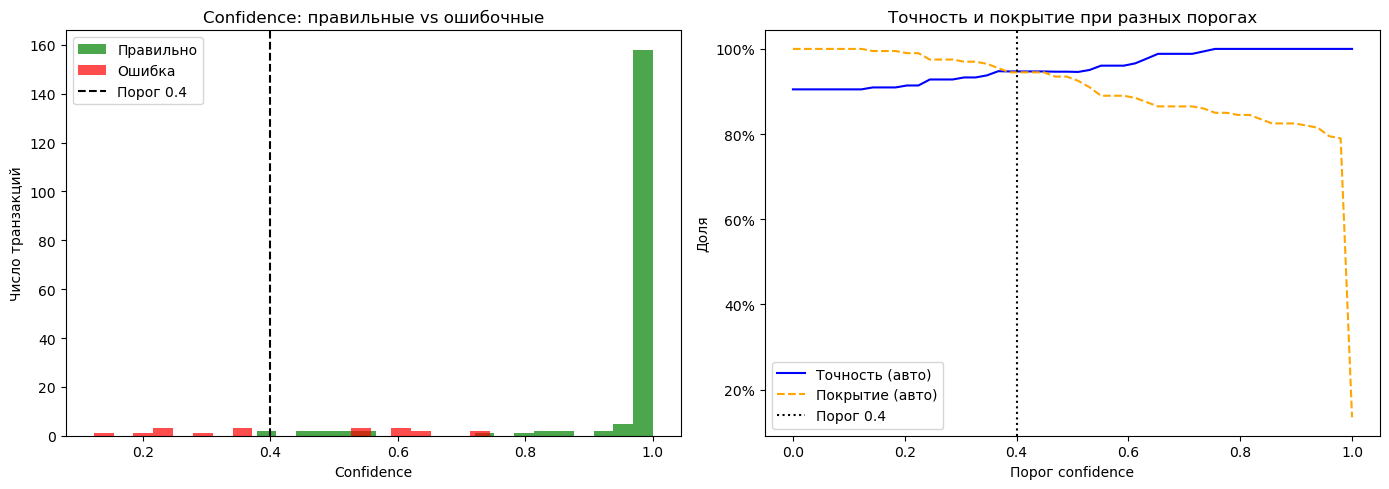

Сохранено: confidence_analysis.png


In [25]:
# Распределение confidence для правильных и неправильных предсказаний
gold_ml['correct'] = (
    gold_ml['category_code'].apply(norm_code) ==
    gold_ml['pred_code'].apply(norm_code)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма confidence
ax = axes[0]
ax.hist(gold_ml[gold_ml['correct']]['confidence'],  bins=20, alpha=0.7, label='Правильно', color='green')
ax.hist(gold_ml[~gold_ml['correct']]['confidence'], bins=20, alpha=0.7, label='Ошибка',    color='red')
ax.axvline(MLClassifier.THRESHOLD, color='black', linestyle='--', label=f'Порог {MLClassifier.THRESHOLD}')
ax.set_xlabel('Confidence')
ax.set_ylabel('Число транзакций')
ax.set_title('Confidence: правильные vs ошибочные')
ax.legend()

# Precision @ threshold sweep
ax2 = axes[1]
thresholds = np.linspace(0, 1, 50)
precisions, coverages = [], []
for t in thresholds:
    mask = gold_ml['confidence'] >= t
    if mask.sum() == 0:
        precisions.append(np.nan)
        coverages.append(0)
    else:
        precisions.append(gold_ml[mask]['correct'].mean())
        coverages.append(mask.mean())

ax2.plot(thresholds, precisions, label='Точность (авто)', color='blue')
ax2.plot(thresholds, coverages, label='Покрытие (авто)', color='orange', linestyle='--')
ax2.axvline(MLClassifier.THRESHOLD, color='black', linestyle=':', label=f'Порог {MLClassifier.THRESHOLD}')
ax2.set_xlabel('Порог confidence')
ax2.set_ylabel('Доля')
ax2.set_title('Точность и покрытие при разных порогах')
ax2.legend()
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.savefig(ROOT / 'notebooks' / 'confidence_analysis.png', dpi=120)
plt.show()
print('Сохранено: confidence_analysis.png')

In [26]:
# Итоговый анализ порога
thr = MLClassifier.THRESHOLD
auto_mask = gold_ml['confidence'] >= thr
review_mask = ~auto_mask

auto_precision  = gold_ml[auto_mask]['correct'].mean()   if auto_mask.sum()   > 0 else 0
auto_coverage   = auto_mask.mean()
review_count    = review_mask.sum()

print(f'Порог confidence = {thr}')
print(f'  Авто-классификация: {auto_coverage:.1%} транзакций, точность {auto_precision:.1%}')
print(f'  На ручную проверку: {review_count} / {len(gold_ml)} ({review_mask.mean():.1%})')
print()
print('Смысл порога: если confidence < 0.40, модель «не уверена» — описание неоднозначное')
print('или содержит слова из нескольких категорий одновременно. Такие транзакции')
print('отправляются оператору — он проверяет вручную за несколько секунд.')

Порог confidence = 0.4
  Авто-классификация: 94.5% транзакций, точность 94.7%
  На ручную проверку: 11 / 200 (5.5%)

Смысл порога: если confidence < 0.40, модель «не уверена» — описание неоднозначное
или содержит слова из нескольких категорий одновременно. Такие транзакции
отправляются оператору — он проверяет вручную за несколько секунд.


In [27]:
# Примеры транзакций с низким confidence
print('=== Примеры транзакций, отправленных на ручную проверку ===')
display(
    gold_ml[gold_ml['needs_review']][
        ['description', 'category_name', 'pred_name', 'confidence']
    ].head(10)
)

=== Примеры транзакций, отправленных на ручную проверку ===


,description,category_name,pred_name,confidence
11,"Тепловая энергия за период 01-28.02.2025, коли...","Коммунальные услуги (электро, газ, тепло)","Коммунальные услуги (электро, газ, тепло)",0.3784
18,Восстановление бух. учёта,Бухгалтерские и аудиторские услуги,Рекламные услуги,0.2436
20,"Тепловая энергия за период 01-28.02.2025, коли...","Коммунальные услуги (электро, газ, тепло)","Коммунальные услуги (электро, газ, тепло)",0.3840
30,Молочная продукция оптом,Продукты питания (опт),Сельхозпродукция,0.3660
35,"Бизнес-консультации по выходу на рынок РФ, кол...",Консалтинговые услуги,Юридические услуги,0.1941
37,Услуги: восстановление бух. учёта,Бухгалтерские и аудиторские услуги,Юридические услуги,0.3053
57,Бизнес-консультации по выходу на рынок РФ,Консалтинговые услуги,Юридические услуги,0.3453
104,"Бизнес-консультации по выходу на рынок РФ, кол...",Консалтинговые услуги,Юридические услуги,0.2245
111,Обслуживание счёта № KZ12...,Банковские и финансовые услуги,Рекламные услуги,0.1232
157,Восстановление бух. учёта,Бухгалтерские и аудиторские услуги,Рекламные услуги,0.2436


## 7. Итоговые выводы

1. **Keyword baseline** прост и интерпретируем, но имеет два ограничения:
   - Не покрывает 100% транзакций (нет ключевых слов → нет предсказания)
   - Конфликт слов между категориями снижает точность (напр. «консультац» есть в 69.10 и 70.22)

2. **TF-IDF + LogReg** обучается на авто-размеченных транзакциях и:
   - Покрывает **100%** описаний
   - Как правило, имеет более высокий macro F1
   - Обучение занимает ~10 секунд на 80k строк

3. **Систематические ошибки:**
   - **69.10 ↔ 70.22** (Юр. услуги vs Консалтинг): слово «консультац» присутствует в обоих словарях. Решение: добавить приоритетные правила («адвокат», «суд», «иск» → только 69.10; «стратегич», «ВЭД» → только 70.22)
   - **49.41 ↔ 29.10** (Перевозка vs Транспорт): слово «транспорт» неоднозначно. Решение: добавить контекст — наличие «маршрут»/«тонн» → 49.41; «запчасти»/«автомобиль» → 29.10

4. **Confidence threshold = 0.40**: транзакции ниже порога направляются на ручную разметку. Это обеспечивает высокую точность для авто-классифицированных записей при приемлемой нагрузке на операторов.